# 05 · Fields and modes

Before you run a full FDTD simulation it helps to see two things: the
**waveguide modes** (the transverse field patterns the guide supports, and
their effective indices) and the **permittivity** the solver actually
rasterizes from your layout + technology.

Both are **local and free** — the mode solver is tidy3d's *local* plugin (pure
on-CPU linear algebra, no cloud task, no credits), and the permittivity grid is
the same rasterizer the kernel engines use. This whole notebook runs offline.

In [1]:
from pathlib import Path

import gdsfactory as gf
import matplotlib.pyplot as plt

from gds_fdtd.layout.gdsfactory import from_gdsfactory
from gds_fdtd.modes import waveguide_mode
from gds_fdtd.plotting import plot_mode, plot_permittivity
from gds_fdtd.technology import Technology


def _find(rel: str) -> Path:
    for base in (Path.cwd(), *Path.cwd().parents):
        if (base / rel).exists():
            return base / rel
    raise FileNotFoundError(rel)

## 1 · The fundamental mode of a silicon strip

A 500 × 220 nm silicon core (n≈3.48) in oxide (n≈1.44) at 1.55 µm.
`waveguide_mode` builds the cross-section and solves it; the first mode is the
fundamental TE-like mode. Its effective index (~2.44) sets the phase velocity.

20:18:56 PDT WARNING: Using canonical configuration directory at                
             '/home/mustafa/.config/tidy3d'. Found legacy directory at          
             '~/.tidy3d', which will be ignored. Remove it manually or run      
             'tidy3d config migrate --delete-legacy' to clean up.               

20:18:57 PDT WARNING: Use the remote mode solver with subpixel averaging for    
             better accuracy through 'tidy3d.web.run(...)' or the deprecated    
             'tidy3d.plugins.mode.web.run(...)'. Alternatively, you can install 
             the package 'tidy3d-extras' using 'pip install "tidy3d"' and set   
             'config.simulation.use_local_subpixel=True'.                       

             WARNING: Permittivity spatial data array does not fully cover the  
             requested region.                                                  

mode 0: n_eff = 2.4441
mode 1: n_eff = 1.8011


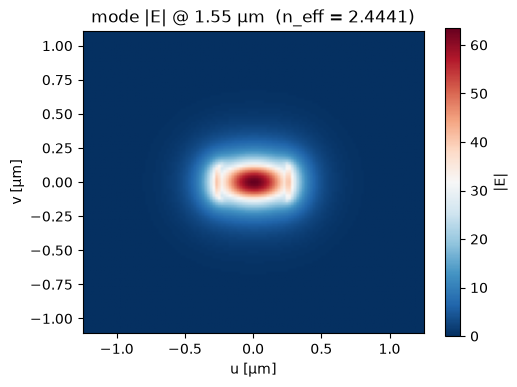

In [2]:
modes = waveguide_mode(
    width_um=0.5, height_um=0.22, n_core=3.476, n_clad=1.444, wavelength_um=1.55, n_modes=2
)
for i, m in enumerate(modes):
    print(f"mode {i}: n_eff = {m.n_eff.real:.4f}")

plot_mode(modes[0], field="E")  # total |E| of the fundamental mode
plt.show()

It's TE-like: the transverse **Ex** component dominates (in-plane
polarization), while **Ey** is small.

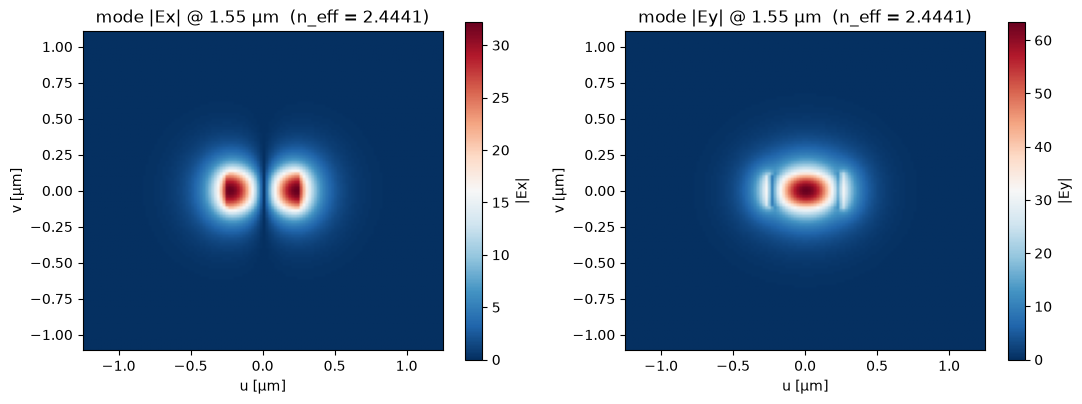

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
plot_mode(modes[0], field="Ex", ax=ax[0])
plot_mode(modes[0], field="Ey", ax=ax[1])
fig.tight_layout()
plt.show()

## 2 · Index contrast sets the mode

The upper core of the escalator (`10_cookbook`) is silicon **nitride**
(n≈2.0) — a much lower index, so its mode is larger and its effective index
lower. Solving both explains why routing between them needs an adiabatic
taper (their modes must be matched along the transition):

20:18:58 PDT WARNING: Permittivity spatial data array does not fully cover the  
             requested region.                                                  

Si strip  n_eff = 2.4441
SiN strip n_eff = 1.6271


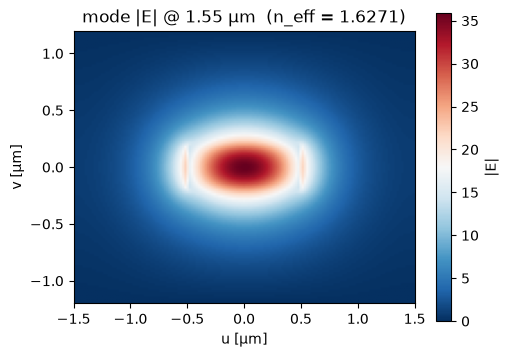

In [4]:
sin = waveguide_mode(width_um=1.0, height_um=0.4, n_core=1.997, n_clad=1.444, wavelength_um=1.55)
print(f"Si strip  n_eff = {modes[0].n_eff.real:.4f}")
print(f"SiN strip n_eff = {sin[0].n_eff.real:.4f}")
plot_mode(sin[0], field="E")
plt.show()

## 3 · The permittivity the solver sees

The mode above is analytic; a real run rasterizes your component + technology
onto a grid. `plot_permittivity` shows that √ε cross-section — the same one the
kernel engines (beamz, fdtdz) integrate. Here, a straight waveguide's
core-in-cladding cross-section:

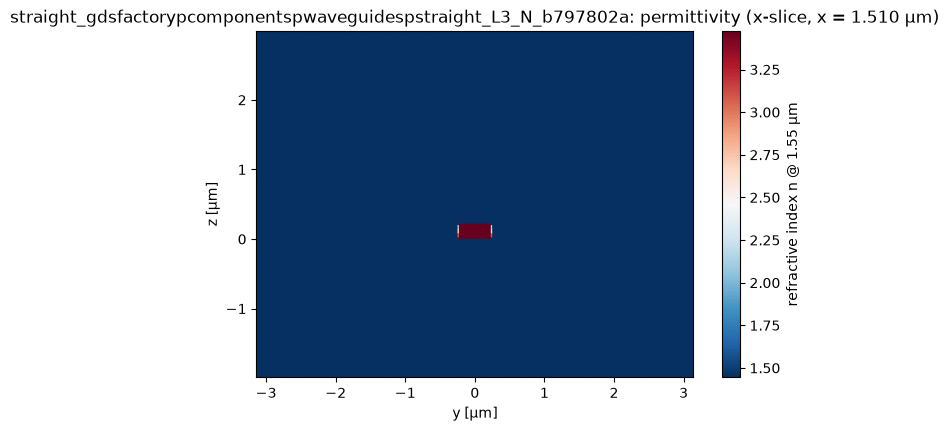

In [5]:
gf.gpdk.PDK.activate()
tech = Technology.from_yaml(_find("examples/tech.yaml"))
component = from_gdsfactory(gf.components.straight(length=3), tech)
plot_permittivity(component, axis="x", wavelength_um=1.55)
plt.show()

## 4 · From mode to field — the propagating picture

Everything so far was a *cross-section*: the transverse mode and the index it
rides in. A run stitches those together into the **propagating field**. Here
is the recorded tidy3d |E|² through the SiEPIC y-branch (the device of `03`
and `07`): the TE0 mode from §1, launched at `opt1`, splitting into two —
drawn on the solver's true (non-uniform) grid coordinates.

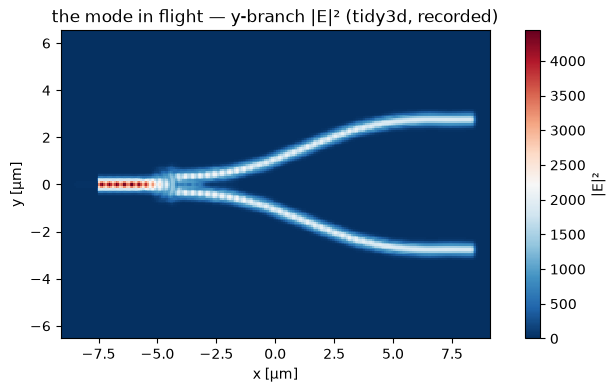

In [6]:
import numpy as np  # noqa: E402

fld = np.load(_find("examples/03_first_simulation/recorded/ybranch_tidy3d_field.npz"))
fig, ax = plt.subplots(figsize=(9, 4))
im = ax.pcolormesh(fld["x"], fld["y"], fld["mag2"].T, shading="nearest", cmap="RdBu_r")
ax.set_aspect("equal")
fig.colorbar(im, ax=ax, label="|E|²")
ax.set_xlabel("x [µm]")
ax.set_ylabel("y [µm]")
ax.set_title("the mode in flight — y-branch |E|² (tidy3d, recorded)")
plt.show()

## Recap & next

`waveguide_mode` + `plot_mode` give you modes and effective indices offline for
free; `plot_permittivity` shows the discretized index the solver integrates;
and a run's field profile shows the mode actually propagating. Next:
**`06_convergence_and_caching`** — how fine a mesh you actually need, and
how to never pay for the same run twice.